# Training (YOLO Model)

This notebook contains the code used to perform the main training loop for the YOLO26 based human pose estimation model. The actual training code in implemented in `detect.py`.

In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We now train the custom YOLO head with the complete dataset. 

In [ ]:
model = detect.CustomHeadedYolo(path="../nets")

# Train for a maximum of 150 epochs on the complete dataset.
detect.train_epochs_in(150, "../nets/yolo", "../stats/yolo", model)

epoch 0; train: loss 23.96707421341793; val: loss 17.456232109848333
epoch 1; train: loss 21.461238066946265; val: loss 17.40213156719597
epoch 2; train: loss 20.92326167081812; val: loss 16.422925014885106
epoch 3; train: loss 20.44303590568911; val: loss 16.30137573942846
epoch 4; train: loss 19.903285650515645; val: loss 16.485544749668666
epoch 5; train: loss 19.79274931982104; val: loss 15.894319981944804
epoch 6; train: loss 19.74294467486413; val: loss 16.400858411983567
epoch 7; train: loss 19.450989237505265; val: loss 15.721544693927376
epoch 8; train: loss 19.274216318662283; val: loss 15.852562164773746
epoch 9; train: loss 19.13663292640204; val: loss 15.704991846668475
epoch 10; train: loss 19.092665027065348; val: loss 15.629227735558334
epoch 11; train: loss 18.866905084773062; val: loss 15.39481612614223
epoch 12; train: loss 18.638716020548653; val: loss 15.436829391790896
epoch 13; train: loss 18.82430918952346; val: loss 16.3766772017187
epoch 14; train: loss 18.550

In [8]:
util.NetStorage.training_stats("../stats/yolo").sort_values("step") \
    .to_csv("../stats/yolo.csv", index=False)

#### Training and Validation Loss Curves

Below we will examine the training and validation loss curves for the training run.

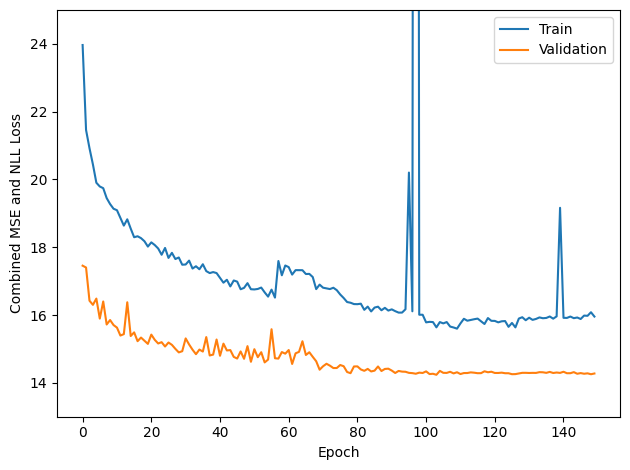

In [19]:
df = pd.read_csv("../stats/yolo.csv").sort_values("step")

plt.plot(df["step"], df["tr_loss"], label="Train")
plt.plot(df["step"], df["val_loss"], label="Validation")
plt.ylabel("Combined MSE and NLL Loss")
plt.xlabel("Epoch")
plt.ylim(13, 25)
plt.legend()
plt.tight_layout()
plt.savefig(f"../../presentation1/figures/lcurve-yolo.pdf",
            format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()